In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import pickle

plt.style.use(['science','notebook'])

In [2]:
tau_max = 300
ks = [1, 5,10, 20, 30, 50]
windows = [10, 20, 30, 40 ,50 ,100]
taus = np.arange(-tau_max,tau_max)

imbs = np.zeros((len(ks),len(windows),len(taus),2))
for ik, k in enumerate(ks):
    for jw, window in enumerate(windows):
        _, _, imbs[ik,jw] = pickle.load(open(f"./pickles/best25feats_k{k}_window{window}_taumax{tau_max}.p","rb"))

### Fix window length, variable k

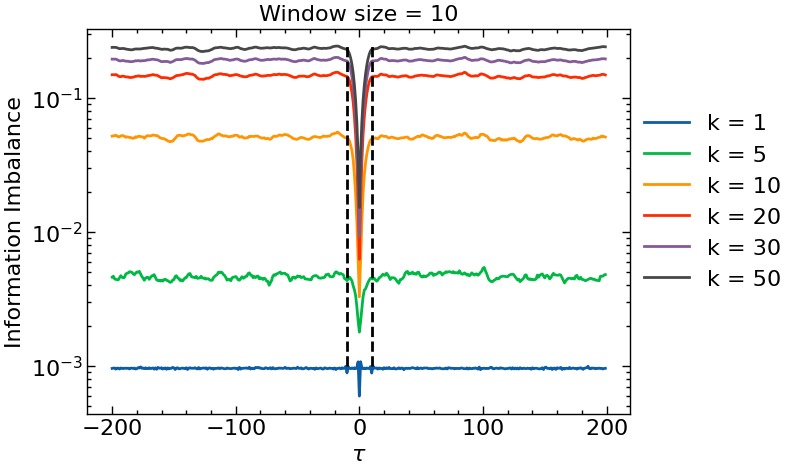

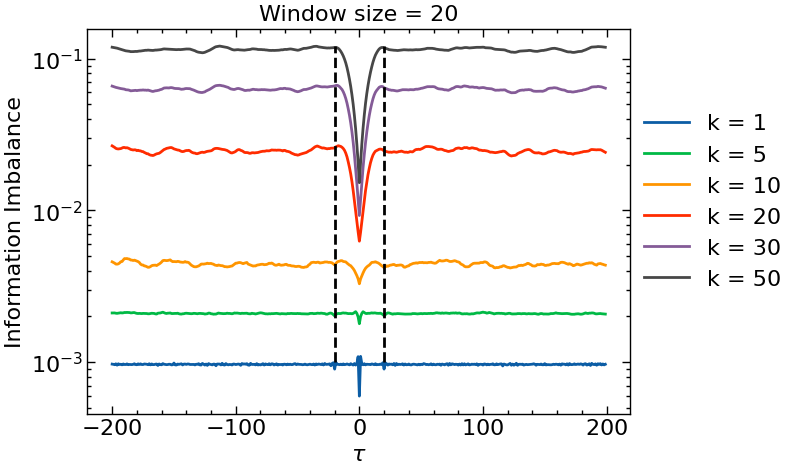

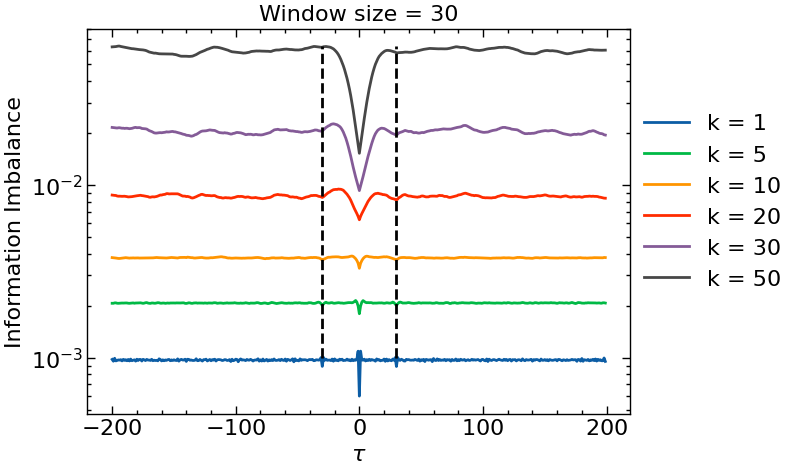

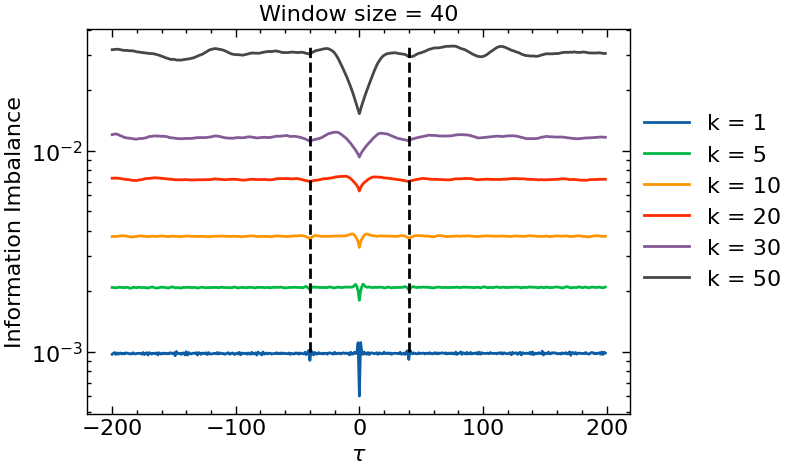

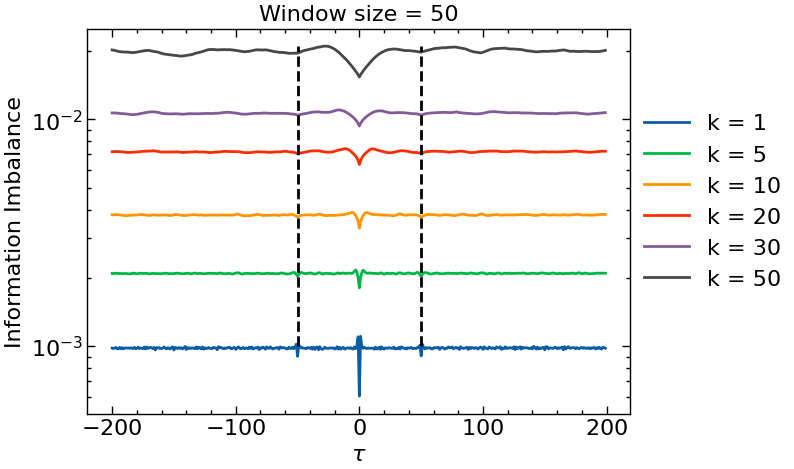

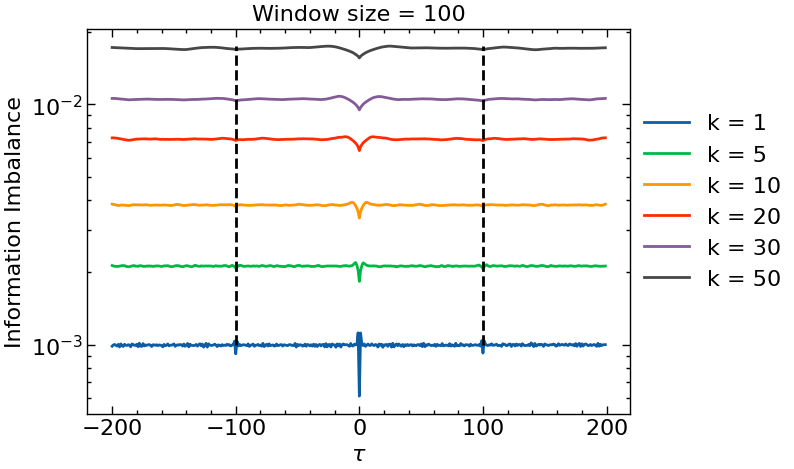

In [36]:
for jw, window in enumerate(windows):
    plt.figure(figsize=(7,5))
    for ik, k in enumerate(ks):
        plt.plot(taus[100:-100], imbs[ik,jw,100:-100,0], label=f"k = {k}")
    plt.vlines(-window, 0.001, np.max(imbs[-1,jw,:,0][100:-100]), linestyle="--", color="black")
    plt.vlines(window, 0.001, np.max(imbs[-1,jw,:,0][100:-100]), linestyle="--", color="black")
    plt.legend(loc=(1.01,0.3))
    plt.xlabel("$\\tau$")
    plt.ylabel("Information Imbalance")
    plt.yscale("log")
    plt.title(f"Window size = {window}")
    plt.savefig(f"./figures/window{window}.pdf", dpi=300)
    plt.show()

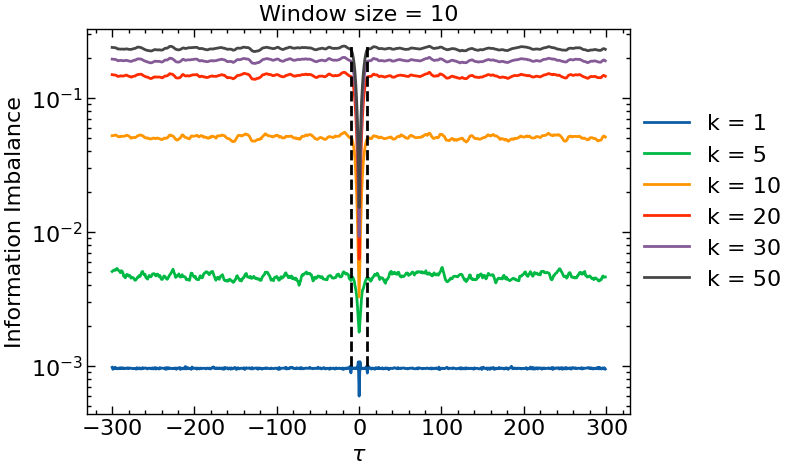

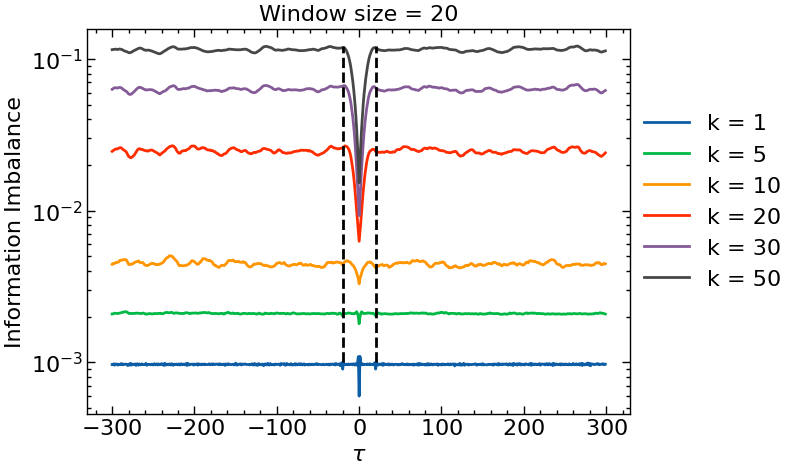

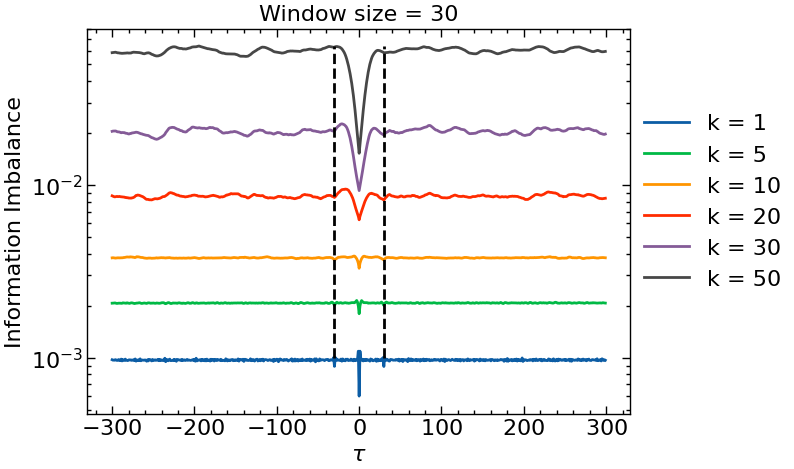

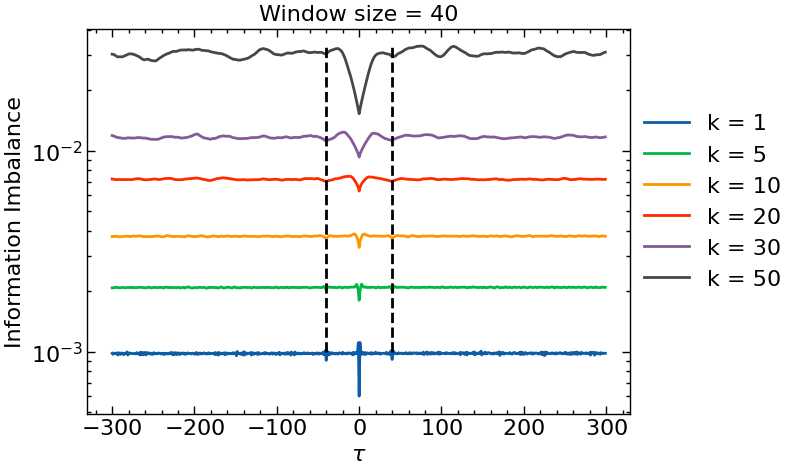

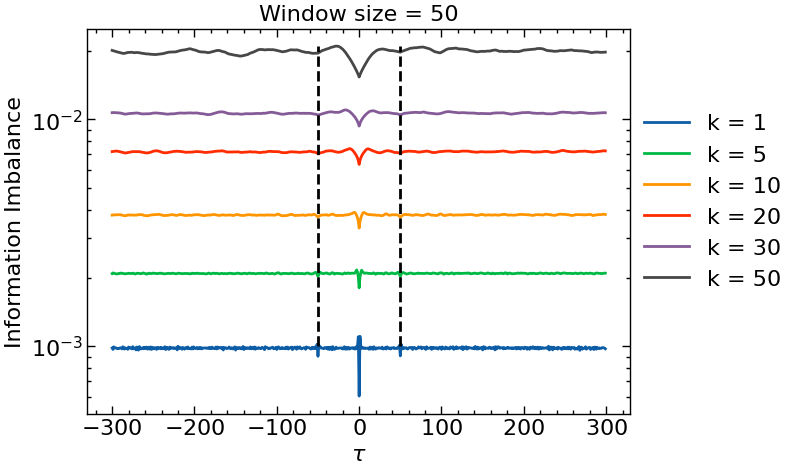

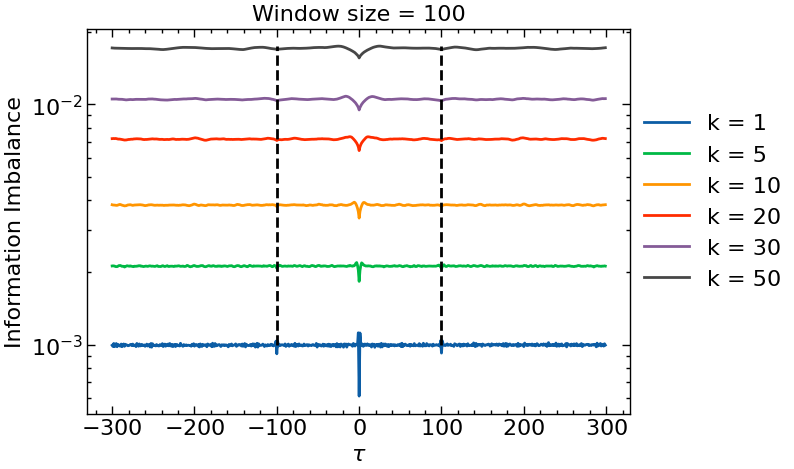

In [33]:
for jw, window in enumerate(windows):
    plt.figure(figsize=(7,5))
    for ik, k in enumerate(ks):
        plt.plot(taus, imbs[ik,jw,:,0], label=f"k = {k}")
    plt.vlines(-window, 0.001, np.max(imbs[-1,jw,:,0][100:-100]), linestyle="--", color="black")
    plt.vlines(window, 0.001, np.max(imbs[-1,jw,:,0][100:-100]), linestyle="--", color="black")
    plt.legend(loc=(1.01,0.3))
    plt.xlabel("$\\tau$")
    plt.ylabel("Information Imbalance")
    plt.yscale("log")
    plt.title(f"Window size = {window}")
    #plt.savefig(f"./figures/window{window}.pdf", dpi=300)
    plt.show()

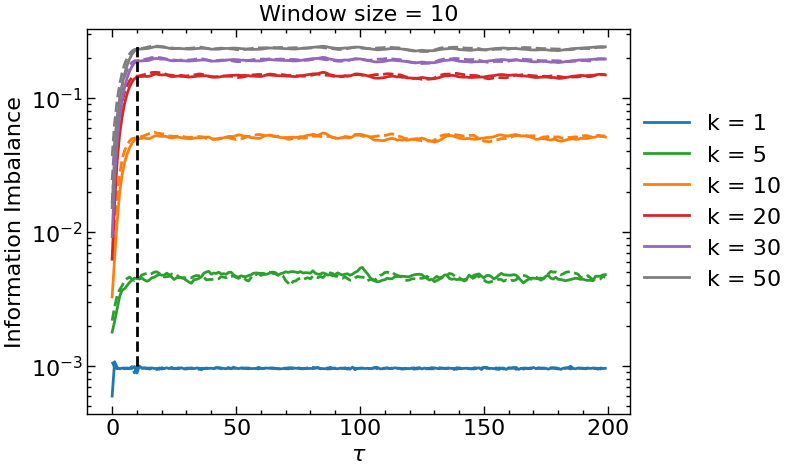

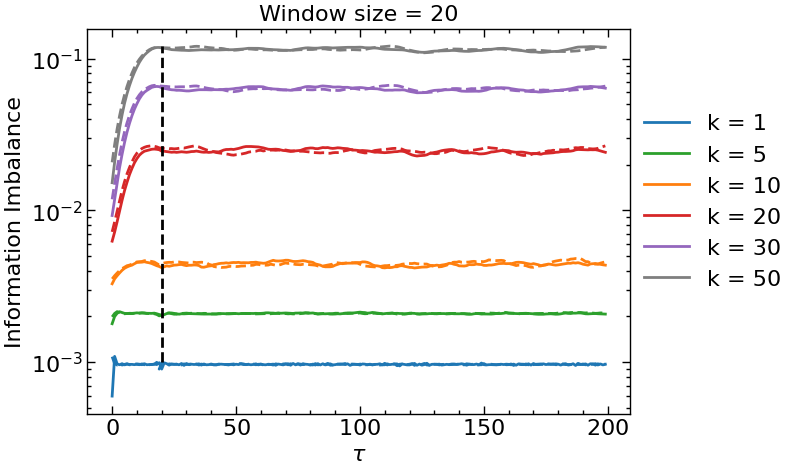

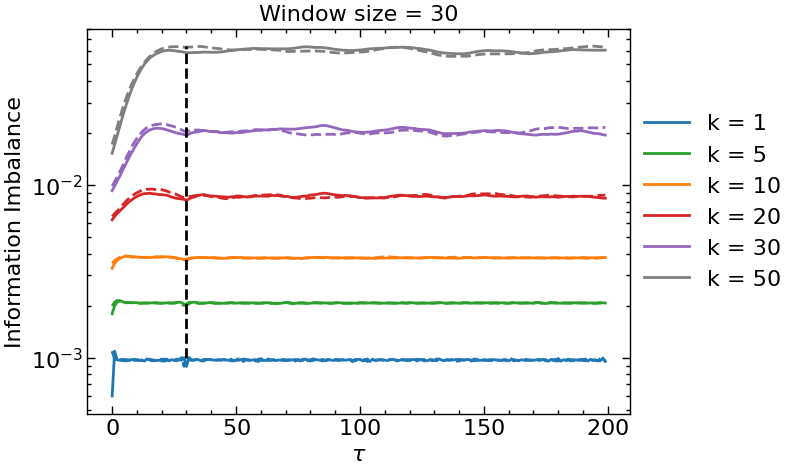

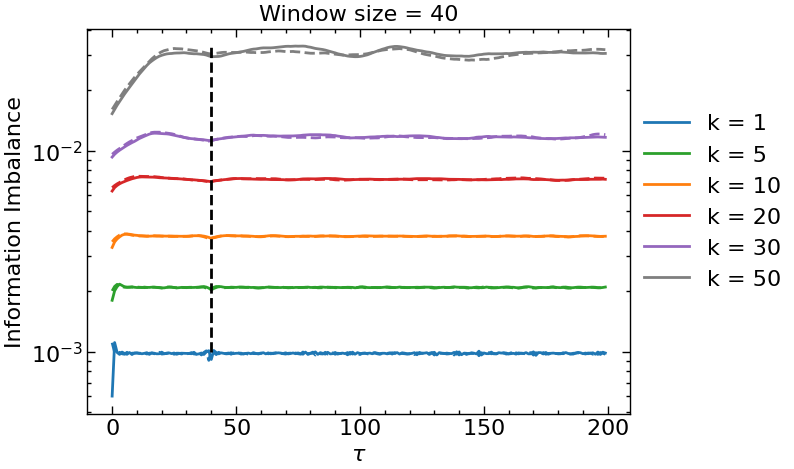

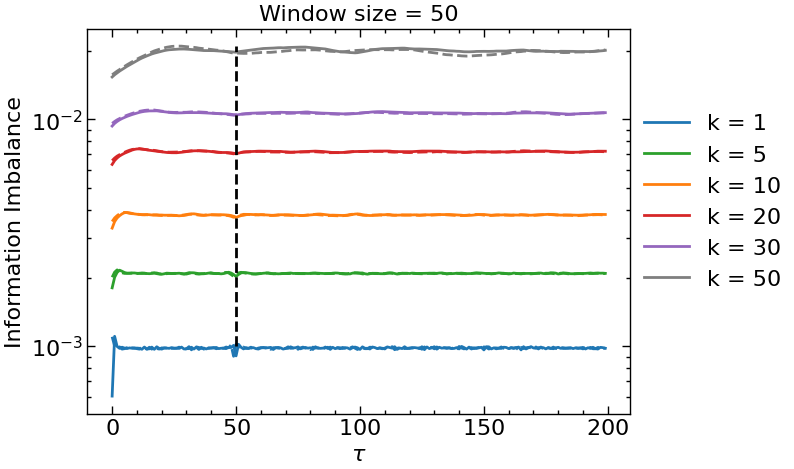

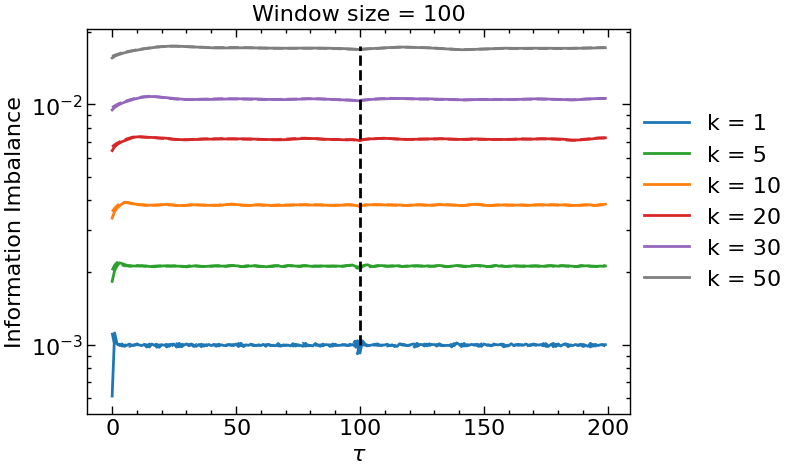

In [32]:
colors = ["tab:blue","tab:green","tab:orange","tab:red","tab:purple","tab:gray"]

for jw, window in enumerate(windows):
    plt.figure(figsize=(7,5))
    for ik, k in enumerate(ks):
        plt.plot(taus[len(taus)//2:-100], imbs[ik,jw,:,0][len(taus)//2:-100], label=f"k = {k}", color=colors[ik])
        plt.plot(taus[len(taus)//2:-100], np.flip(imbs[ik,jw,:,0][100:-len(taus)//2]), "--", color=colors[ik])
    #plt.vlines(-window, 0.001, np.max(imbs[-1,jw,:,0][100:-100]), linestyle="--", color="black")
    plt.vlines(window, 0.001, np.max(imbs[-1,jw,:,0][100:-100]), linestyle="--", color="black")
    plt.legend(loc=(1.01,0.3))
    plt.xlabel("$\\tau$")
    plt.ylabel("Information Imbalance")
    plt.yscale("log")
    plt.title(f"Window size = {window}")
    plt.savefig(f"./figures/window{window}.pdf", dpi=300)
    plt.show()

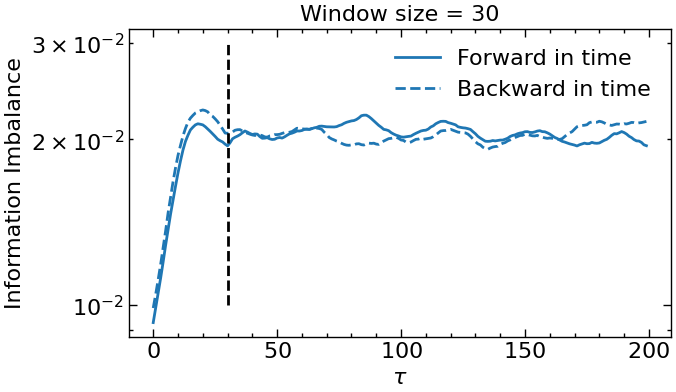

In [7]:
# for report
colors = ["tab:blue","tab:green","tab:orange","tab:red","tab:purple","tab:gray"]

jw = 2 # window_Size = 30
window = windows[jw]
plt.figure(figsize=(7,4))
ik = 4 # k = 30
k = ks[ik]

plt.plot(taus[len(taus)//2:-100], imbs[ik,jw,:,0][len(taus)//2:-100], color="tab:blue", label=f"Forward in time")
plt.plot(taus[len(taus)//2:-100], np.flip(imbs[ik,jw,:,0][100:-len(taus)//2]), "--", color="tab:blue", label=f"Backward in time")
plt.vlines(window, 0.01, 0.03, linestyle="--", color="black")
plt.legend()
plt.xlabel("$\\tau$")
plt.ylabel("Information Imbalance")
plt.yscale("log")
plt.title(f"Window size = {window}")
plt.show()